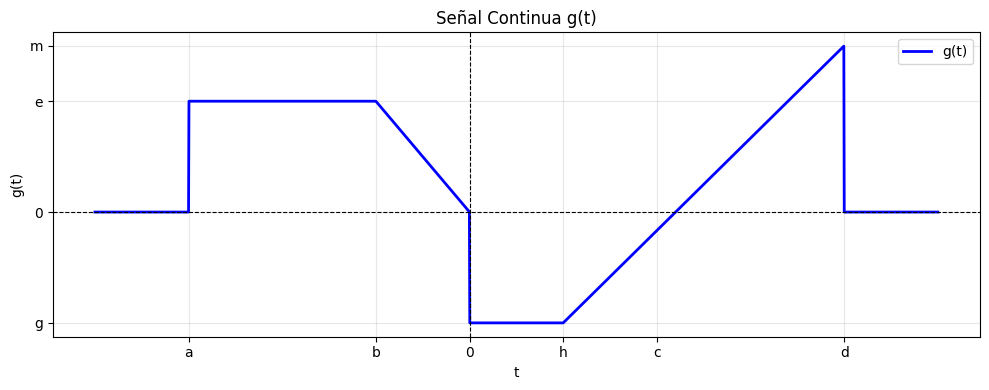

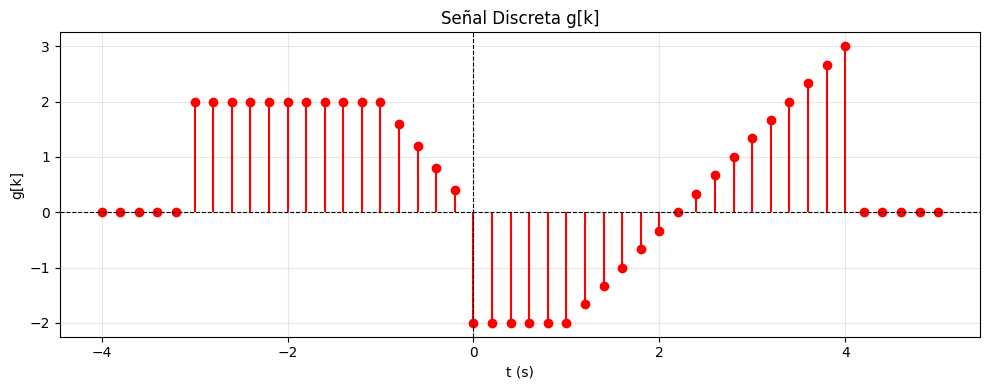

Índices de inflexión (máximo entero):
- En t = a (-3s): k = -15
- En t = b (-1s): k = -5
- En t = 0 (0.0s): k = 0
- En t = h (1s): k = 5
- En t = c (2s): k = 10
- En t = d (4s): k = 20


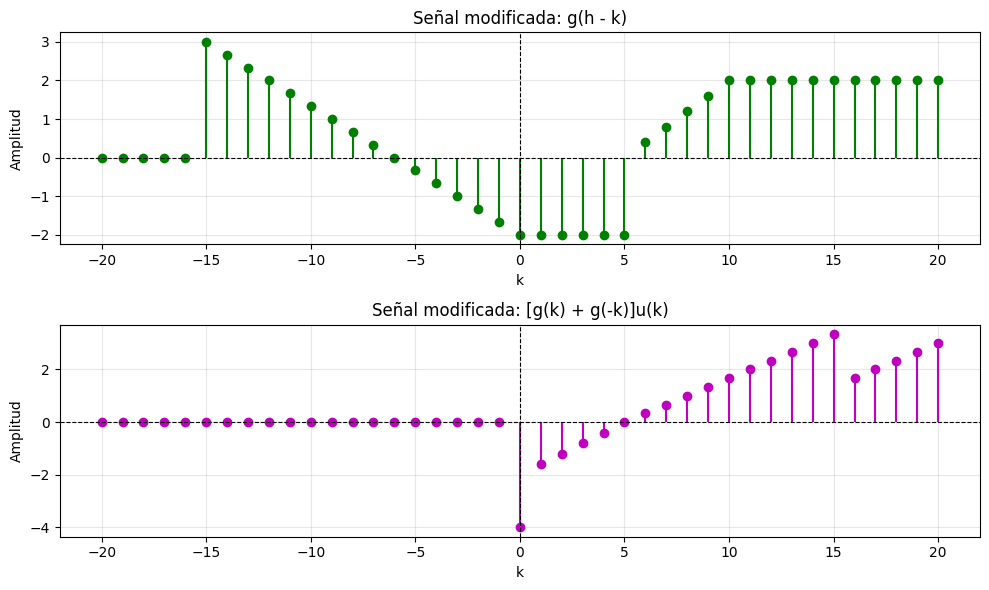

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros según la estructura correcta de la imagen
a, b, h, c, d = -3, -1, 1, 2, 4
e, g_val, m = 2, -2, 3

# Rango temporal continuo
t = np.linspace(a - 1, d + 1, 2000)

def g_continua(t_val):
    g = np.zeros_like(t_val)
    for i, ti in enumerate(t_val):
        if a <= ti < b:
            g[i] = e
        elif b <= ti < 0:
            # Rampa descendente desde (b, e) hasta el origen (0, 0)
            g[i] = e + (0 - e) * (ti - b) / (0 - b)
        elif 0 <= ti <= h:
            # Tramo constante en el nivel g desde t=0 hasta t=h
            g[i] = g_val
        elif h < ti <= d:
            # Rampa ascendente desde (h, g) hasta (d, m), cruzando el eje en c
            g[i] = g_val + (m - g_val) * (ti - h) / (d - h)
        else:
            g[i] = 0
    return g

# Representación exacta con plt.plot()
plt.figure(figsize=(10, 4))
plt.plot(t, g_continua(t), 'b-', linewidth=2, label='g(t)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks([a, b, 0, h, c, d], ['a', 'b', '0', 'h', 'c', 'd'])
plt.yticks([g_val, 0, e, m], ['g', '0', 'e', 'm'])
plt.title('Señal Continua g(t)')
plt.xlabel('t')
plt.ylabel('g(t)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show

# Bloque para implementar y graficar la señal discreta g[k]
k_min = int(np.floor((a - 1) / Ts))
k_max = int(np.floor((d + 1) / Ts))
k = np.arange(k_min, k_max + 1)
tk = k * Ts
gk = g_continua(tk)

plt.figure(figsize=(10, 4))
plt.stem(tk, gk, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Señal Discreta g[k]')
plt.xlabel('t (s)')
plt.ylabel('g[k]')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cálculo y visualización de los índices de inflexión utilizando la función de máximo entero (np.floor)
puntos_inflexion = {'a': a, 'b': b, '0': 0.0, 'h': h, 'c': c, 'd': d}

print("Índices de inflexión (máximo entero):")
for nombre, val in puntos_inflexion.items():
    k_idx = int(np.floor(val / Ts))
    print(f"- En t = {nombre} ({val}s): k = {k_idx}")

# Rango de índices discretos para evaluar las operaciones
k_indices = np.arange(-20, 21)

# 1. Señal modificada: g(h - k)
# Evaluamos la señal continua usando el argumento desplazado y reflejado (h - k*Ts)
g_h_minus_k = g_continua(h - k_indices * Ts)

# 2. Señal combinada: [g(k) + g(-k)] u(k)
g_k = g_continua(k_indices * Ts)
g_minus_k = g_continua(-k_indices * Ts)
u_k = np.heaviside(k_indices, 1)  # Escalón unitario u(k)
comb_signal = (g_k + g_minus_k) * u_k

# Gráficas de ambas señales en una misma figura con dos subgráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.stem(k_indices, g_h_minus_k, linefmt='g-', markerfmt='go', basefmt=' ')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Señal modificada: g(h - k)')
ax1.set_xlabel('k')
ax1.set_ylabel('Amplitud')
ax1.grid(True, alpha=0.3)

ax2.stem(k_indices, comb_signal, linefmt='m-', markerfmt='mo', basefmt=' ')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Señal modificada: [g(k) + g(-k)]u(k)')
ax2.set_xlabel('k')
ax2.set_ylabel('Amplitud')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()